# Comment ditulis sebagai markdown files

# 1. Gradient
Dalam Kalkulus multivariable, Gradient merupakan vektor arah turun tercepat suatu fungsi optimalisasi. Dalam Neural network arah turun tersebut merupakan Fungsi optimalisasi tersebut merupakan Loss function, dan parameter vector yang diubah adalah weight dan bias pada neuron. Karena bentuk fungsi opimasi yang ada pada neural network berbentuk hyperplane, digunakan 2 buat element vector untuk mempermudah visualisasi.

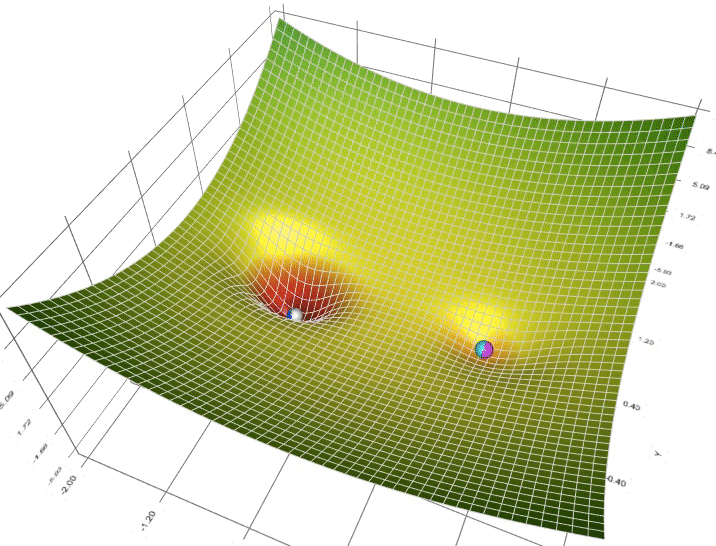

#2. Permodelan Gradient Descent

### Penjelasan Arsitektur
1. Setiap neuron node disimpan sebagai compnode object dengan attribute output dan gradient.
2. CompNode dapat diinherit oleh Class operand seperti add, power, square, sub, dan multiply. Hal ini dilakukan karena dalam perhitungan back propagation dibutuhkan penyimpanan value output dan gradient untuk menghitung nilai selanjutnya.
3. Digunakan Polimorfisme pada masing-masing method Forward dan Backward yang digunakan. Polimorfisme digunakan karena setiap Class-node memiliki Forward dan Backward yang berbeda.  
4. Class Constantnode dibuat untuk menyipan input pada layer pertama.
5. Class Tape menyimpanan rekaman graf komputasi. method Komputasi menyimpan node komputasi yang dijalankan. method Forward menjalankan urutan komputasi secara berurutan, vice versa dengan method Backward.


In [ ]:
import numpy as np

# Pendefinisian class utama untuk menggambarkan komputasi pada setiap node
class CompNode:
  def __init__(self, tape):
    tape.add(self)
    self.output = None
    self.gradient = np.array(0.0)

  def set_gradient(self, gradient):
    self.gradient = np.array(gradient, dtype=float)

  def add_gradient(self, gradient):
    self.gradient = self.gradient + np.array(gradient, dtype=float)

  def forward(self):
    pass

  def backward(self):
    pass

class Tape:
  def __init__(self):
    self.computations = []

  def add(self, compNode: CompNode):
    self.computations.append(compNode)

  def forward(self):
    for compNode in self.computations:
      compNode.forward()

  def backward(self):
  # Reset semua gradient menjadi 0
    for compNode in self.computations:
      compNode.set_gradient(np.array(0.0))

    self.computations.reverse()

    # Gradient awal dari loss (MSE)
    initial_grad = self.computations[0].output - self.computations[0].target
    self.computations[0].set_gradient(initial_grad)

    for compNode in self.computations:
      compNode.backward()

  # TAMBAHAN PENTING: Reset tape
  def reset(self):
    self.computations.clear()


# Pendefinisian fungsi untuk menggambarkan layer pertama berisi input nilai x dan y
class ConstantNode(CompNode):
  def __init__(self, value, tape):
    super().__init__(tape)
    self.output = np.array(value, dtype=float)

  def forward(self):
    pass

  def backward(self):
    pass

# Pendefinisian fungsi untuk menggambarkan layer kedua berisi f(x,y) = x*y
class Multiply(CompNode):
  def __init__(self, left: CompNode, right: CompNode, tape):
    self.left = left
    self.right = right
    super().__init__(tape)
  def forward(self):
    self.output = self.left.output * self.right.output

  def backward(self):
    # Turunan xy terhadap x adalah y, dan terhadap y adalah x.
    self.left.add_gradient(self.right.output * self.gradient)
    self.right.add_gradient(self.left.output * self.gradient)

# Pendefinisian fungsi untuk menggambarkan layer ketiga berisi g(h)=h^2
class Square(CompNode):
  def __init__(self, num: CompNode, target, tape):
    self.num = num
    self.target = np.array(target, dtype=float)
    self.loss = None
    super().__init__(tape)

  def forward(self):
    self.output = self.num.output ** 2
    self.loss = (self.output - self.target) ** 2 / 2

  def backward(self):
    # Sesuai Chain Rule: gradien_sebelumnya = gradien_skrng * turunan_lokal
    self.num.add_gradient(2 * self.num.output * self.gradient)

# Mendefinisikan fungsi perhitungan untuk forward pass
def f_numpy(a, tape):
  # b = a * 2
  two = ConstantNode(2.0, tape)
  b = Multiply(a, two, tape)
  tape. forward()

  # Pengecekan 2-norm (Euclidean-norm)
  while np.linalg.norm(b.output) < 1000:
    b = Multiply(b, two, tape)
    tape. forward()

  # Pengecekan sum() > 0
  if np.sum(b.output) > 0:
    c = b
  else:
    # c = 100 * b
    hundred = ConstantNode(100.0, tape)
    c = Multiply(hundred, b, tape)
    tape. forward()

  return b


#2.2 Permodelan Gradient Descent

### Tape dibuat untuk mensimulasikan neural network pada sederhana Contoh.

1. Dilakukan inisiasi input dengan constantnode
2. mendefinisikan operasi perkalian (l2)
3. Mendefinisikan operasi kuadrat (l3)
4. Menjalankan proses forward

In [ ]:
# Percobaan simulasi proses forward seperti yang terlihat pada gambar
arsi_coba = Tape()

# Inisialisasi input sebagai ConstantNode
x = ConstantNode(3.0, arsi_coba)
y = ConstantNode(2.0, arsi_coba)

# Operasi perkalian f(x,y) = x * y
h = Multiply(x, y, arsi_coba)

# Operasi kuadrat g(h) = h^2 dengan target 30 untuk perhitungan gradien
o = Square(h, 30.0, arsi_coba)

# Menjalankan proses forward
arsi_coba. forward()

print("Outputs")
print(f"x: {x.output}\ny: {y.output}\nh: {h.output}\no: {o.output} \nl: {o.loss}")

Outputs
x: 3.0
y: 2.0
h: 6.0
o: 36.0 
l: 198.0


In [ ]:
# Percobaan simulasi proses backward seperti yang terlihat pada gambar
arsi_coba.backward()

print("Gradients")
print(f"o: {o.gradient}\nh: {h.gradient}\nx: {x.gradient}\ny: {y.gradient}")

Gradients
o: 6.0
h: 72.0
x: 144.0
y: 216.0


#2.2 Permodelan Gradient Descent

### Tape dibuat untuk mensimulasikan neural network pada sederhana Contoh.

1. Fungsi pertama z = u * x, di mana u dianggap sebagai konstanta, sehingga termasuk fungsi linear terhadap x. Oleh karena itu, gradiennya = u .
2. Pada Fungsi kedua y = x^2, yaitu fungsi kuadrat, sehingga gradiennya 2x.
3. Akibatnya terdapat 2 hasil yang berbeda sesuai 2 pendekatan tersebut.

In [ ]:
tape_baru = Tape()
data_x = np.arange(4.0)
x = ConstantNode(data_x, tape_baru)
print(x.output)

# Forward Pass: y = x * x
y_node = Square(x, 0.0, tape_baru)
tape_baru. forward()

print("Output dari x^2 = ", y_node.output)

# Pemecahan beberapa fungsi (misalkan dimasukkan ke dalam variable u)
u = ConstantNode(y_node.output, tape_baru)

# z = u * x
z = Multiply(u, x, tape_baru)
tape_baru. forward()
print("Output dari y * x = ", z.output)

# z.sum().backward()
z.set_gradient(np.ones_like(z.output))

# Jalankan backward secara manual
for node in reversed(tape_baru. computations):
  node.backward()

# Menampilkan hasil x.grad

# Mengecek apakah nilai dari hasil backward z'(x) sama dengan nilai u (output dari node u)
print(x.gradient == u.output)

# Jika ingin memastikan seluruh elemen di dalam array sama persis
print(np.all(x.gradient == u.output))

# Melakukan simulai perhitungan dari nilai gradien x saja
tape_baru.reset()
x = ConstantNode(data_x, tape_baru)
y_node = Square(x, 0.0, tape_baru)
tape_baru. forward()
print("Nilai x =", x.output)
print("Output dari x^2 = ", y_node.output)

# Melakukan set gradient output dengan nilai nol
y_node.set_gradient(np.ones_like(y_node.output))

# Menjalankan backward pass pada tape secara manual
for node in reversed(tape_baru.computations):
  node.backward()

# Menampilkan hasil x.gradient
print(f"x.gradient = {x.gradient}")

# Mengecek apakah nilai hasil backward y' sama dengan 2 * x
print(x.gradient == 2 * x.output)# Mengecek apakah nilai dari hasil backward z'(x) sama dengan nilai u (output dari node u)
print(x.gradient == u.output)

# Jika ingin memastikan seluruh elemen di dalam array sama persis
print(np.all(x.gradient == u.output))

# Melakukan simulai perhitungan dari nilai gradien x saja
tape_baru.reset()
x = ConstantNode(data_x, tape_baru)
y_node = Square(x, 0.0, tape_baru)
tape_baru. forward()
print("Nilai x =", x.output)
print("Output dari x^2 = ", y_node.output)

# Melakukan set gradient output dengan nilai nol
y_node.set_gradient(np.ones_like(y_node.output))

# Menjalankan backward pass pada tape secara manual
for node in reversed(tape_baru.computations):
  node.backward()

# Menampilkan hasil x.gradient
print(f"x.gradient = {x.gradient}")

# Mengecek apakah nilai hasil backward y' sama dengan 2 * x
print(x.gradient == 2 * x.output)

[0. 1. 2. 3.]
Output dari x^2 =  [0. 1. 4. 9.]
Output dari y * x =  [ 0.  1.  8. 27.]
[ True  True  True  True]
True
Nilai x = [0. 1. 2. 3.]
Output dari x^2 =  [0. 1. 4. 9.]
x.gradient = [0. 2. 4. 6.]
[ True  True  True  True]
[ True False  True False]
False
Nilai x = [0. 1. 2. 3.]
Output dari x^2 =  [0. 1. 4. 9.]
x.gradient = [0. 2. 4. 6.]
[ True  True  True  True]


2.4. Gradients dan control flow
pada bagian ini gradient dihitung langsung dengan pendekatan control flow python

In [ ]:
# Inisialisasi Tape baru
tape_f = Tape()
val_a = np.random. randn()

a = ConstantNode(val_a, tape_f)

# Melakukan forward pass dengan memanggil fungsi f yang sudah disesuaika
d = f_numpy(a, tape_f)

# Menampilkan hasil menggunakan atribut .output
print(f"a = {a.output}")
print(f"f(a) = {d.output}")

a = -0.20943376422431859
f(a) = -1715.6813965256179


In [ ]:
# Melakukan backward pass
d.set_gradient(1.0)

# Menjalankan backward
for node in reversed(tape_f.computations):
  node.backward()

# Menampilkan verifikasi gradien
print(f"Verifikasi Gradien: {a.gradient == (d.output / a.output)}")

# Inisialisasi kembali gradient menjadi nol
a.set_gradient(0.0)

Verifikasi Gradien: True


#MLP

In [ ]:
# Memuat library yang dibutuhkan dalam pemrosesan data dan pembuatan model
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Pengaturan untuk menentukan device komputasi yang akan digunakan
device = "cpu"
print(f"Using device: {device}")


Using device: cpu


# 3.1 Data Generation
### Pada data generation digunakan hyperparameter sebesar 100 sample
### Label output dibuat berdasarkan fungsi optimalisasi yang dibuat

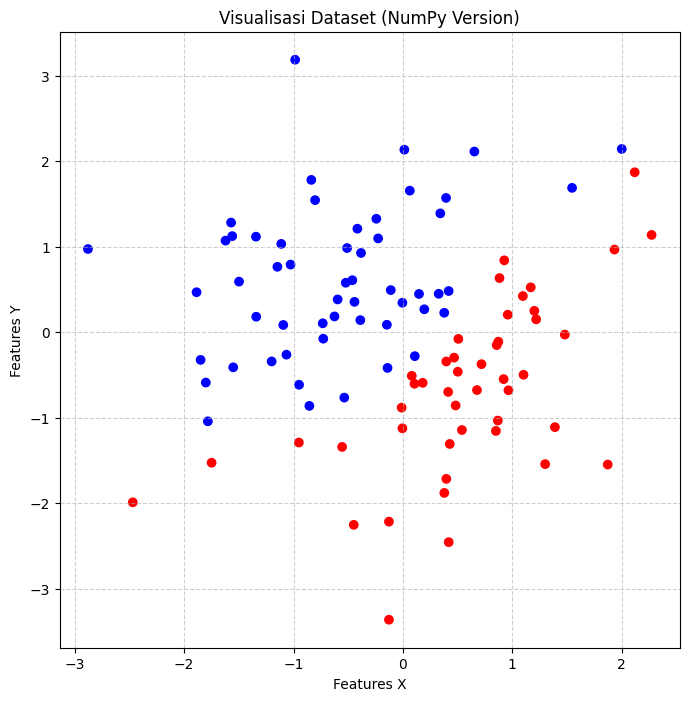

In [ ]:
num_samples = 100

# Menghasilkan data input (x,y)
features_x = np.random.randn(num_samples)
features_y = np.random.randn(num_samples)

# Menghasilkan data output (o)
labels_o = (4 * features_x ** 2) + (12 * features_x) + (-3 * features_y ** 3) + (-6 * features_y) - 4

# Visualisasi data
labels_view = ['red' if o >= 0 else 'blue' for o in labels_o]

plt.figure(figsize=(8, 8))
plt.scatter(features_x, features_y, c=labels_view)
plt.xlabel('Features X')
plt.ylabel('Features Y')
plt.title('Visualisasi Dataset (NumPy Version)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#3.2 Data Preparation
### Data training dan testing dipisah
### Class Data loader dibuat untuk keperluan visualisasi

In [ ]:
features_x = features_x.reshape(-1, 1)
features_y = features_y.reshape(-1, 1)

data_x = np.concatenate((features_x, features_y), axis=1)

print(f"Shape data_x: {data_x.shape}")

batch_size = 10
train_size = 0.7
num_train = int(num_samples * train_size)

# Pembagian data ke training dan testing data
x_train = data_x[0:num_train]
y_train = labels_o[0:num_train].reshape(-1, 1)

x_test = data_x[num_train:num_samples]
y_test = labels_o[num_train:num_samples].reshape(-1, 1)

print(f"Jumlah data training: {len(x_train)}")
print(f"Jumlah data testing: {len(x_test)}")

# Konversi dalam format "Dataset"
training_set = (x_train, y_train)
test_set = (x_test, y_test)

# Membuat class DataLoader sederhana agar struktur kode tidak berubah
class DataLoader:
  def __init__(self, dataset, batch_size=1, shuffle=False):
    self.x, self.y = dataset
    self.batch_size = batch_size
    self.shuffle = shuffle
    self.n = len(self.x)
  def __iter__(self):
    # Membuat indeks untuk shuffling
    indices = np.arange(self.n)
    if self.shuffle:
      np.random. shuffle(indices)

    # Melakukan looping per batch
    for start in range(0, self.n, self.batch_size):
      end = min(start + self.batch_size, self.n)
      batch_idx = indices[start:end]
      yield self.x[batch_idx], self.y[batch_idx]

  def __len__(self):
    # Mengembalikan jumlah total batch
    return (self.n + self.batch_size - 1) // self.batch_size

# Pembuatan DataLoader untuk kedua kumpulan data
training_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

Shape data_x: (100, 2)
Jumlah data training: 70
Jumlah data testing: 30


#3.3 Model Definition
### Menambah fungsi pembantu untuk MLP

In [ ]:
class Add(CompNode):
  def __init__(self, left: CompNode, right: CompNode, tape):
    self.left = left
    self.right = right
    super().__init__(tape)

  def forward(self):
    self.output = self.left.output + self.right.output

  def backward(self):
    self.left.add_gradient(self.gradient)
    self.right.add_gradient(self.gradient)

class Sub(CompNode):
  def __init__(self, left: CompNode, right: CompNode, tape):
    self.left = left
    self.right = right
    super().__init__(tape)

  def forward(self):
    self.output = self.left.output - self.right.output

  def backward(self):
    self.left.add_gradient(self.gradient)
    self.right.add_gradient(-self.gradient)

class Power(CompNode):
  def __init__(self, node: CompNode, exponent, tape):
    self.node = node
    self.exponent = exponent
    super().__init__(tape)

  def forward(self):
    self.output = np.power(self.node.output, self.exponent)

  def backward(self):
    local_grad = self.exponent * np.power(self.node.output, self.exponent - 1)
    self.node.add_gradient(self.gradient * local_grad)

  def squared_loss_numpy(y_pred_node, y_true, tape):
    """ 0.5 * (y_pred - y_true)^2 """
    y_true = y_true.reshape(-1, 1)
    target = ConstantNode(y_true, tape)
    diff = Sub(y_pred_node, target, tape)
    sq = Power(diff, 2.0, tape)
    half = ConstantNode(0.5, tape)
    loss = Multiply(half, sq, tape)
    loss.target = y_true
    return loss
  def sgd_numpy(params, lr, batch_size):
    for param in params:
      # Update nilai output berdasarkan gradien yang sudah dikumpulkan
      param.output = param.output - (lr * param.gradient / batch_size)

# Fungsi Default
### Pendefinisian fungsi yang akan dioptimalisasi dengan training MLP

In [ ]:
# f(x,y)1= 2x^2 - 3y +6
def fungsi_xy1_numpy(X_node, w_val, b_val, tape):
  fx = ConstantNode(X_node.output[:, 0:1], tape) # Slicing (N, 1)
  fy = ConstantNode(X_node.output[:,1:2], tape)

  w0_n, w1_n, b_n = ConstantNode(w_val[0], tape), ConstantNode(w_val[1], tape), ConstantNode(b_val, tape)

  term1 = Multiply(w0_n, Square(fx, 0.0, tape), tape)
  term2 = Multiply(w1_n, fy, tape)
  out = Add(Sub(term1, term2, tape), b_n, tape)
  return out, [w0_n, w1_n, b_n]

# f(x,y)2 = 4x - y^3 -2
def fungsi_xy2_numpy(X_node, w_val, b_val, tape):
  fx = ConstantNode(X_node.output[:, 0:1], tape)
  fy = ConstantNode(X_node.output[:, 1:2], tape)

  w0_n, w1_n, b_n = ConstantNode(w_val[0], tape), ConstantNode(w_val[1], tape), ConstantNode(b_val, tape)

  term1 = Multiply(w0_n, fx, tape)
  term2 = Multiply(w1_n, Power(fy, 3.0, tape), tape)
  out = Sub(Sub(term1, term2, tape), b_n, tape)
  return out, [w0_n, w1_n, b_n]

# f(x,y)3 = -4x + 5y - 10
def fungsi_xy3_numpy(X_node, w_val, b_val, tape):
  fx = ConstantNode(X_node.output[:, 0:1], tape)
  fy = ConstantNode(X_node.output[:, 1:2], tape)

  w0_n, w1_n, b_n = ConstantNode(w_val[0], tape), ConstantNode(w_val[1], tape), ConstantNode(b_val, tape)

  term1 = Multiply(w0_n, fx, tape)
  term2 = Multiply(w1_n, fy, tape)
  out = Sub(Sub(term2, term1, tape), b_n, tape)
  return out, [w0_n, w1_n, b_n]

# o = 2h1 + 3h2 - 10
def fungsi_h1h2_numpy(h1, h2, w_val, b_val, tape):
  w0_n, w1_n, b_n = ConstantNode(w_val[0], tape), ConstantNode(w_val[1], tape), ConstantNode(b_val, tape)

  term1 = Multiply(w0_n, h1, tape)
  term2 =Multiply(w1_n, h2, tape)
  out = Sub(Add(term1, term2, tape), b_n, tape)
  return out, [w0_n, w1_n, b_n]

# o = w1*h1 + w2*h2 + w3*h3 - b
def fungsi_h1h2h3_numpy(h1, h2, h3, w_val, b_val, tape):
    w0_n = ConstantNode(w_val[0], tape)
    w1_n = ConstantNode(w_val[1], tape)
    w2_n = ConstantNode(w_val[2], tape)
    b_n  = ConstantNode(b_val, tape)

    term1 = Multiply(w0_n, h1, tape)
    term2 = Multiply(w1_n, h2, tape)
    term3 = Multiply(w2_n, h3, tape)

    out = Sub(Add(Add(term1, term2, tape), term3, tape), b_n, tape)
    return out, [w0_n, w1_n, w2_n, b_n]


#Fungsi 3 Neuron
### Implementasi dengan 3 Neuron

In [ ]:
import numpy as np

# Hyperparameters
lr = 0.01
num_epochs = 100

# Inisialisasi parameter sebagai numpy array biasa
np.random.seed(42)

w_fxy1 = np.random.randn(2) * 0.1
b_fxy1 = np.zeros(1)

w_fxy2 = np.random.randn(2) * 0.1
b_fxy2 = np.zeros(1)

w_fh1h2 = np.random.randn(2) * 0.1
b_fh1h2 = np.zeros(1)

print("Parameter initialized successfully")

Parameter initialized successfully


In [ ]:
loss_train_history = []
loss_test_history = []

# training loop
for epoch in range(num_epochs):
  epoch_loss = 0.0

  # Training Phase
  for batch_x, batch_y in training_loader:
    tape = Tape()
    X_node = ConstantNode(batch_x, tape)

    # Forward Pass
    h1, nodes1 = fungsi_xy1_numpy(X_node, w_fxy1, b_fxy1, tape)
    h2, nodes2 = fungsi_xy2_numpy(X_node, w_fxy2, b_fxy2, tape)
    y_pred, nodes_out = fungsi_h1h2_numpy(h1, h2, w_fh1h2, b_fh1h2, tape)

    loss_node = squared_loss_numpy(y_pred, batch_y, tape)
    tape.forward()

    # Backward Pass
    batch_size = len(batch_y)
    # Gradient awal untuk Mean Squared Error
    loss_node.set_gradient(np.ones_like(loss_node.output) / batch_size)

    for node in reversed(tape. computations):
      node.backward()

    # update parameters
    # Update fxy1 (w0, w1, b)
    w_fxy1[0] -= lr * np.mean(nodes1[0].gradient)
    w_fxy1[1] -= lr * np.mean(nodes1[1].gradient)
    b_fxy1 -= lr * np.mean(nodes1[2].gradient)

    # Update fxy2 (w0, w1, b)
    w_fxy2[0] -= lr * np.mean(nodes2[0].gradient)
    w_fxy2[1] -= lr * np.mean(nodes2[1].gradient)
    b_fxy2 -= lr * np.mean(nodes2[2].gradient)

    # Update fh1h2 (w0, w1, b)
    w_fh1h2[0] -= lr * np.mean(nodes_out[0].gradient)
    w_fh1h2[1] -= lr * np.mean(nodes_out[1].gradient)
    b_fh1h2 -= lr * np.mean(nodes_out[2].gradient)

    epoch_loss += np.mean(loss_node.output)

  avg_train_loss = epoch_loss / len(training_loader)
  loss_train_history.append(avg_train_loss)

    # Test Phase
  test_epoch_loss = 0.0
  for batch_x_test, batch_y_test in test_loader:
    test_tape = Tape()
    X_test_node = ConstantNode(batch_x_test, test_tape)

    h1_t, _= fungsi_xy1_numpy(X_test_node, w_fxy1, b_fxy1, test_tape)
    h2_t, _= fungsi_xy2_numpy(X_test_node, w_fxy2, b_fxy2, test_tape)
    y_test_pred, _ = fungsi_h1h2_numpy(h1_t, h2_t, w_fh1h2, b_fh1h2, test_tape)
    loss_test_node = squared_loss_numpy(y_test_pred, batch_y_test, test_tape)
    test_tape.forward()

    test_epoch_loss += np.mean(loss_test_node.output)

  avg_test_loss = test_epoch_loss / len(test_loader)
  loss_test_history.append(avg_test_loss)

  # Logging tiap 10 epoch
  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

Epoch [1/100] | Train Loss: 18.382949 | Test Loss: 39.126690
Epoch [10/100] | Train Loss: 15.353413 | Test Loss: 18.941341
Epoch [20/100] | Train Loss: 10.302053 | Test Loss: 7.995187
Epoch [30/100] | Train Loss: 6.527768 | Test Loss: 5.467642
Epoch [40/100] | Train Loss: 4.415539 | Test Loss: 4.125568
Epoch [50/100] | Train Loss: 2.496025 | Test Loss: 2.360837
Epoch [60/100] | Train Loss: 1.079589 | Test Loss: 1.894875
Epoch [70/100] | Train Loss: 0.509867 | Test Loss: 1.140461
Epoch [80/100] | Train Loss: 0.377423 | Test Loss: 0.375242
Epoch [90/100] | Train Loss: 0.153332 | Test Loss: 0.253483
Epoch [100/100] | Train Loss: 0.082552 | Test Loss: 0.128529


#3.4 Model Evaluation

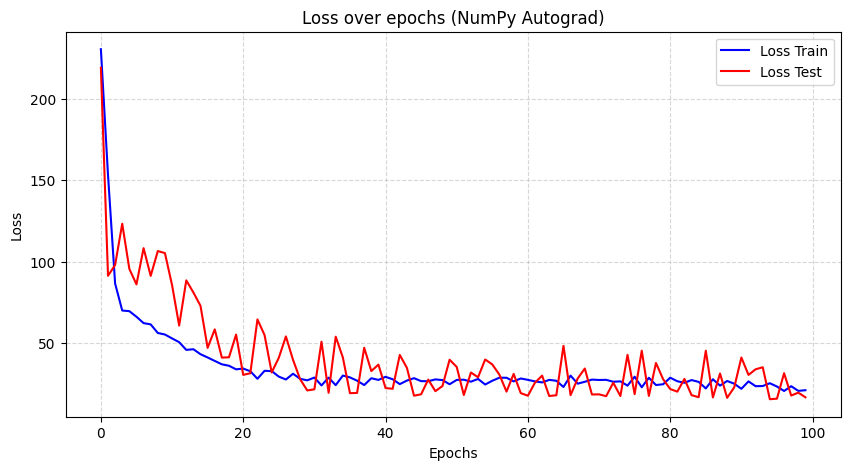

Pada fungsi(x,y)1 :
w1=2   ; w1_learn=-0.7392
w2=-3  ; w2_learn=-0.3378
b=6    ; b_learn=0.0145

Pada fungsi(x,y)2 :
w1=4   ; w1_learn=3.4189
w2=-1  ; w2_learn=1.2275
b=-2   ; b_learn=-0.0642

Pada fungsi(h1,h2) :
w1=2   ; w1_learn=-0.8109
w2=3   ; w2_learn=3.0662
b=10   ; b_learn=0.0186



In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_train_history, '-', color='blue', label='Loss Train' )
plt.plot(loss_test_history, '-', color='red', label='Loss Test' )
plt.title('Loss over epochs (NumPy Autograd)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.grid(True, linestyle= '--', alpha=0.5)
plt.show()

# Memperlihatkan perbandingan bobot yang sebenarnya dan bobot hasil learning

print("Pada fungsi(x,y)1 :")
print(f"w1=2   ; w1_learn={w_fxy1[0]:.4f}")
print(f"w2=-3  ; w2_learn={w_fxy1[1]:.4f}")
print(f"b=6    ; b_learn={b_fxy1[0]:.4f}\n")

print("Pada fungsi(x,y)2 :")
print(f"w1=4   ; w1_learn={w_fxy2[0]:.4f}")
print(f"w2=-1  ; w2_learn={w_fxy2[1]:.4f}")
print(f"b=-2   ; b_learn={b_fxy2[0]:.4f}\n")

print("Pada fungsi(h1,h2) :")
print(f"w1=2   ; w1_learn={w_fh1h2[0]:.4f}")
print(f"w2=3   ; w2_learn={w_fh1h2[1]:.4f}")
print(f"b=10   ; b_learn={b_fh1h2[0]:.4f}\n")

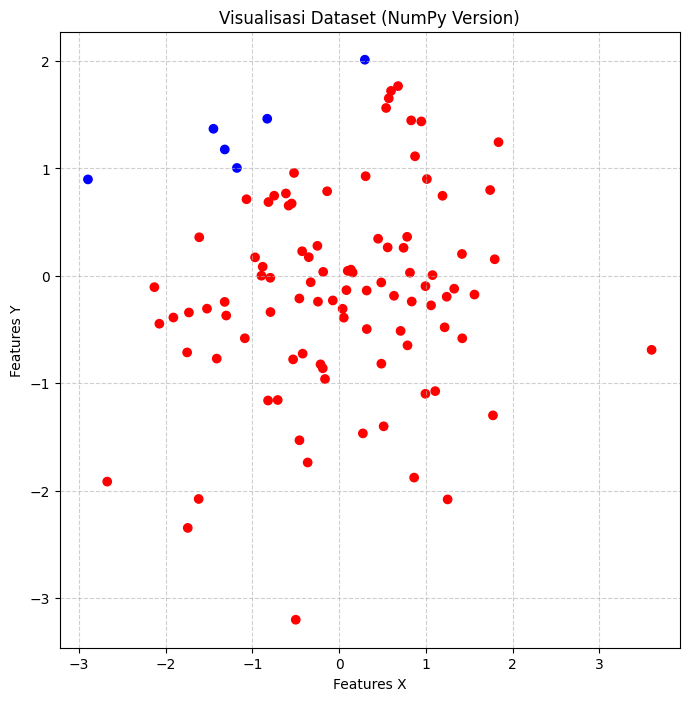

Shape data_x: (100, 2)
Jumlah data training: 70
Jumlah data testing: 30


In [ ]:
num_samples = 100

# Menghasilkan data input (x,y)
features_x = np.random.randn(num_samples)
features_y = np.random.randn(num_samples)

# Menghasilkan data output (o)
labels_o = (4 * features_x ** 2) + (28 * features_x) + (-3 * features_y ** 3) + (-26 * features_y) + 51

# Visualisasi data
labels_view = ['red' if o >= 0 else 'blue' for o in labels_o]

plt.figure(figsize=(8, 8))
plt.scatter(features_x, features_y, c=labels_view)
plt.xlabel('Features X')
plt.ylabel('Features Y')
plt.title('Visualisasi Dataset (NumPy Version)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

features_x = features_x.reshape(-1, 1)
features_y = features_y.reshape(-1, 1)

data_x = np.concatenate((features_x, features_y), axis=1)

print(f"Shape data_x: {data_x.shape}")

batch_size = 10
train_size = 0.7
num_train = int(num_samples * train_size)

# Pembagian data ke training dan testing data
x_train = data_x[0:num_train]
y_train = labels_o[0:num_train].reshape(-1, 1)

x_test = data_x[num_train:num_samples]
y_test = labels_o[num_train:num_samples].reshape(-1, 1)

print(f"Jumlah data training: {len(x_train)}")
print(f"Jumlah data testing: {len(x_test)}")

# Konversi dalam format "Dataset"
training_set = (x_train, y_train)
test_set = (x_test, y_test)

# Membuat class DataLoader sederhana agar struktur kode tidak berubah
class DataLoader:
  def __init__(self, dataset, batch_size=1, shuffle=False):
    self.x, self.y = dataset
    self.batch_size = batch_size
    self.shuffle = shuffle
    self.n = len(self.x)
  def __iter__(self):
    # Membuat indeks untuk shuffling
    indices = np.arange(self.n)
    if self.shuffle:
      np.random. shuffle(indices)

    # Melakukan looping per batch
    for start in range(0, self.n, self.batch_size):
      end = min(start + self.batch_size, self.n)
      batch_idx = indices[start:end]
      yield self.x[batch_idx], self.y[batch_idx]

  def __len__(self):
    # Mengembalikan jumlah total batch
    return (self.n + self.batch_size - 1) // self.batch_size

# Pembuatan DataLoader untuk kedua kumpulan data
training_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [ ]:
import numpy as np

# Hyperparameters
lr = 0.01
num_epochs = 100

# Inisialisasi parameter sebagai numpy array biasa
np.random.seed(42)

w_fxy1 = np.random.randn(2) * 0.1
b_fxy1 = np.zeros(1)

w_fxy2 = np.random.randn(2) * 0.1
b_fxy2 = np.zeros(1)

w_fxy3 = np.random.randn(2) * 0.1
b_fxy3 = np.zeros(1)

w_fh1h2h3 = np.random.randn(3) * 0.1
b_fh1h2h3 = np.zeros(1)

print("Parameter initialized successfully")

loss_train_history = []
loss_test_history = []

# training loop
for epoch in range(num_epochs):
    epoch_loss = 0.0

    # =========================
    # Training Phase
    # =========================
    for batch_x, batch_y in training_loader:
        batch_x = np.array(batch_x, dtype=float)
        batch_y = np.array(batch_y, dtype=float).reshape(-1, 1)

        tape = Tape()
        X_node = ConstantNode(batch_x, tape)

        # Forward Pass
        h1, nodes1 = fungsi_xy1_numpy(X_node, w_fxy1, b_fxy1, tape)
        h2, nodes2 = fungsi_xy2_numpy(X_node, w_fxy2, b_fxy2, tape)
        h3, nodes3 = fungsi_xy3_numpy(X_node, w_fxy3, b_fxy3, tape)

        y_pred, nodes_out = fungsi_h1h2h3_numpy(
            h1, h2, h3,
            w_fh1h2h3, b_fh1h2h3,
            tape
        )

        loss_node = squared_loss_numpy(y_pred, batch_y, tape)
        tape.forward()

        # Backward Pass
        batch_size = len(batch_y)
        loss_node.set_gradient(np.ones_like(loss_node.output) / batch_size)

        for node in reversed(tape.computations):
            node.backward()

        # =========================
        # Update parameters
        # =========================

        # Update fxy1 (w0, w1, b)
        w_fxy1[0] -= lr * np.mean(nodes1[0].gradient)
        w_fxy1[1] -= lr * np.mean(nodes1[1].gradient)
        b_fxy1    -= lr * np.mean(nodes1[2].gradient)

        # Update fxy2 (w0, w1, b)
        w_fxy2[0] -= lr * np.mean(nodes2[0].gradient)
        w_fxy2[1] -= lr * np.mean(nodes2[1].gradient)
        b_fxy2    -= lr * np.mean(nodes2[2].gradient)

        # Update fxy3 (w0, w1, b)
        w_fxy3[0] -= lr * np.mean(nodes3[0].gradient)
        w_fxy3[1] -= lr * np.mean(nodes3[1].gradient)
        b_fxy3    -= lr * np.mean(nodes3[2].gradient)

        # Update fh1h2h3 (w0, w1, w2, b)
        w_fh1h2h3[0] -= lr * np.mean(nodes_out[0].gradient)
        w_fh1h2h3[1] -= lr * np.mean(nodes_out[1].gradient)
        w_fh1h2h3[2] -= lr * np.mean(nodes_out[2].gradient)
        b_fh1h2h3    -= lr * np.mean(nodes_out[3].gradient)

        epoch_loss += np.mean(loss_node.output)

    avg_train_loss = epoch_loss / len(training_loader)
    loss_train_history.append(avg_train_loss)

    # =========================
    # Test Phase
    # =========================
    test_epoch_loss = 0.0

    for batch_x_test, batch_y_test in test_loader:
        batch_x_test = np.array(batch_x_test, dtype=float)
        batch_y_test = np.array(batch_y_test, dtype=float).reshape(-1, 1)

        test_tape = Tape()
        X_test_node = ConstantNode(batch_x_test, test_tape)

        h1_t, _ = fungsi_xy1_numpy(X_test_node, w_fxy1, b_fxy1, test_tape)
        h2_t, _ = fungsi_xy2_numpy(X_test_node, w_fxy2, b_fxy2, test_tape)
        h3_t, _ = fungsi_xy3_numpy(X_test_node, w_fxy3, b_fxy3, test_tape)

        y_test_pred, _ = fungsi_h1h2h3_numpy(
            h1_t, h2_t, h3_t,
            w_fh1h2h3, b_fh1h2h3,
            test_tape
        )

        loss_test_node = squared_loss_numpy(y_test_pred, batch_y_test, test_tape)
        test_tape.forward()

        test_epoch_loss += np.mean(loss_test_node.output)

    avg_test_loss = test_epoch_loss / len(test_loader)
    loss_test_history.append(avg_test_loss)

    # Logging tiap 10 epoch
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

Parameter initialized successfully
Epoch [1/100] | Train Loss: 2056.677520 | Test Loss: 4340.047270
Epoch [10/100] | Train Loss: 354.183714 | Test Loss: 405.563837
Epoch [20/100] | Train Loss: 33.581577 | Test Loss: 178.024608
Epoch [30/100] | Train Loss: 10.889982 | Test Loss: 104.780969
Epoch [40/100] | Train Loss: 3.788695 | Test Loss: 20.562506
Epoch [50/100] | Train Loss: 0.806691 | Test Loss: 6.903460
Epoch [60/100] | Train Loss: 0.212132 | Test Loss: 0.958370
Epoch [70/100] | Train Loss: 0.044715 | Test Loss: 0.341189
Epoch [80/100] | Train Loss: 0.010538 | Test Loss: 0.060443
Epoch [90/100] | Train Loss: 0.002179 | Test Loss: 0.016726
Epoch [100/100] | Train Loss: 0.000476 | Test Loss: 0.002836


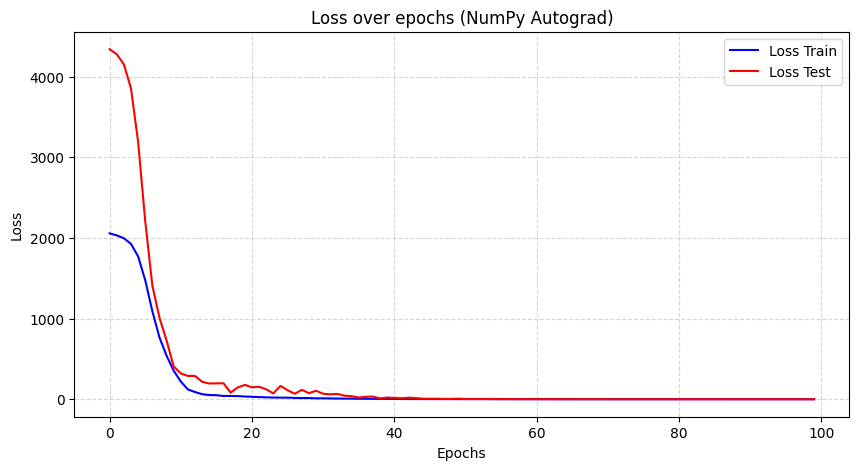

Pada fungsi(x,y)1 :
w1=2   ; w1_learn=0.6954
w2=-3  ; w2_learn=4.4636
b=6    ; b_learn=3.6116

Pada fungsi(x,y)2 :
w1=4   ; w1_learn=4.5179
w2=-1  ; w2_learn=0.4902
b=-2   ; b_learn=-4.4206

Pada fungsi(x,y)3 :
w1=-4   ; w1_learn=4.5179
w2=5  ; w2_learn=0.4902
b=-10   ; b_learn=-4.4206

Pada fungsi(h1,h2,h3) :
w1=2   ; w1_learn=5.7463
w2=3   ; w2_learn=6.1552
w3=-4   ; w3_learn=-0.6418
b=5   ; b_learn=-2.8256



In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_train_history, '-', color='blue', label='Loss Train' )
plt.plot(loss_test_history, '-', color='red', label='Loss Test' )
plt.title('Loss over epochs (NumPy Autograd)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.grid(True, linestyle= '--', alpha=0.5)
plt.show()

# Memperlihatkan perbandingan bobot yang sebenarnya dan bobot hasil learning

print("Pada fungsi(x,y)1 :")
print(f"w1=2   ; w1_learn={w_fxy1[0]:.4f}")
print(f"w2=-3  ; w2_learn={w_fxy1[1]:.4f}")
print(f"b=6    ; b_learn={b_fxy1[0]:.4f}\n")

print("Pada fungsi(x,y)2 :")
print(f"w1=4   ; w1_learn={w_fxy2[0]:.4f}")
print(f"w2=-1  ; w2_learn={w_fxy2[1]:.4f}")
print(f"b=-2   ; b_learn={b_fxy2[0]:.4f}\n")

print("Pada fungsi(x,y)3 :")
print(f"w1=-4   ; w1_learn={w_fxy2[0]:.4f}")
print(f"w2=5  ; w2_learn={w_fxy2[1]:.4f}")
print(f"b=-10   ; b_learn={b_fxy2[0]:.4f}\n")

print("Pada fungsi(h1,h2,h3) :")
print(f"w1=2   ; w1_learn={w_fh1h2h3[0]:.4f}")
print(f"w2=3   ; w2_learn={w_fh1h2h3[1]:.4f}")
print(f"w3=-4   ; w3_learn={w_fh1h2h3[2]:.4f}")
print(f"b=5   ; b_learn={b_fh1h2h3[0]:.4f}\n")
